# trying to extract data

In [7]:
import os
import numpy as np

filter_folder = r"D:\Users\nina\Star_Formation_Histories\Filters"

global_min = np.inf
global_max = -np.inf

for fname in os.listdir(filter_folder):
    if fname.endswith(".txt"):

        filepath = os.path.join(filter_folder, fname)
        data = np.loadtxt(filepath)

        lam_min = data[:, 0].min()
        lam_max = data[:, 0].max()

        global_min = min(global_min, lam_min)
        global_max = max(global_max, lam_max)

        print(f"{fname:20s}  {lam_min:.0f} – {lam_max:.0f} Å")

print("\nOverall wavelength coverage:")
print(f"{global_min:.0f} – {global_max:.0f} Å")

HST_ACS_WFC_F435W.txt  3526 – 4979 Å
HST_ACS_WFC_F606W.txt  4569 – 7283 Å
HST_ACS_WFC_F814W.txt  6738 – 9778 Å
HST_WFC3_IR_F105W.txt  8650 – 12250 Å
HST_WFC3_IR_F125W.txt  10640 – 14390 Å
HST_WFC3_IR_F140W.txt  11370 – 16450 Å
HST_WFC3_IR_F160W.txt  13664 – 17205 Å
JWST_NIRCam_F090W.txt  7836 – 10356 Å
JWST_NIRCam_F115W.txt  9892 – 13282 Å
JWST_NIRCam_F150W.txt  12798 – 17238 Å
JWST_NIRCam_F200W.txt  16904 – 22984 Å
JWST_NIRCam_F277W.txt  23371 – 33015 Å
JWST_NIRCam_F356W.txt  29930 – 42294 Å
JWST_NIRCam_F410M.txt  36740 – 45226 Å
JWST_NIRCam_F444W.txt  37132 – 50996 Å

Overall wavelength coverage:
3526 – 50996 Å


In [8]:
import os
import numpy as np

filter_folder = r"D:\Users\nina\Star_Formation_Histories\Filters"

filter_files = [
    os.path.join(filter_folder, f)
    for f in os.listdir(filter_folder)
    if f.endswith(".txt")
]

filter_files.sort()

print(filter_files)

['D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_ACS_WFC_F435W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_ACS_WFC_F606W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_ACS_WFC_F814W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_WFC3_IR_F105W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_WFC3_IR_F125W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_WFC3_IR_F140W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\HST_WFC3_IR_F160W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F090W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F115W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F150W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F200W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F277W.txt', 'D:\\Users\\nina\\Star_Formation_Histories\\Filters\\JWST_NIRCam_F356W.txt'

In [9]:
import bagpipes as pipes
import numpy as np

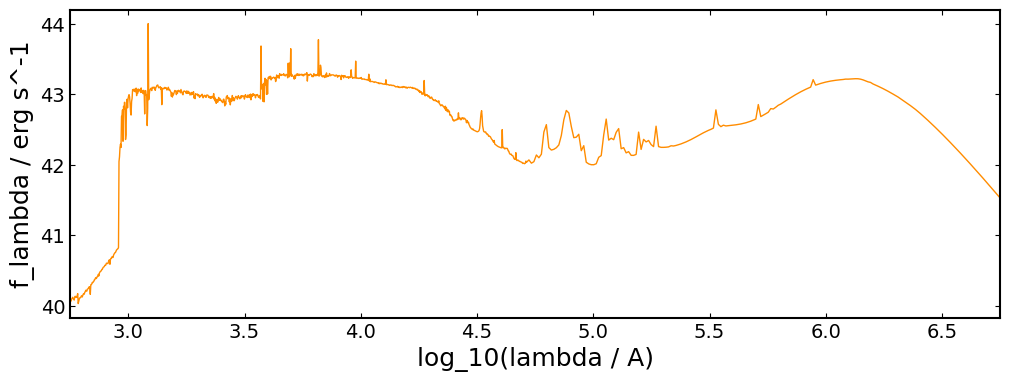

AttributeError: 'NoneType' object has no attribute 'axes'

In [15]:
import numpy as np
import bagpipes as pipes

# Define your galaxy components
dust = {"type": "Calzetti", "Av": 0.2, "eta": 3.}
nebular = {"logU": -3.}
dblplaw = {"tau": 5., "alpha": 2.5, "beta": 10., "massformed": 10., "metallicity": 0.5}
burst1 = {"age": 0.2, "massformed": 7., "metallicity": 1.}
burst2 = {"age": 3., "massformed": 7.5, "metallicity": 0.2}

model_components = {
    "redshift": 0.5,
    "t_bc": 0.01,
    "veldisp": 200.,
    "burst1": burst1,
    "burst2": burst2,
    "dblplaw": dblplaw,
    "dust": dust,
    "nebular": nebular
}

# Build the galaxy model
model = pipes.model_galaxy(model_components, filt_list=filter_files)


import matplotlib.pyplot as plt

# This generates the spectrum plot
fig = model.plot_full_spectrum()

# Extract the data from the figure (lines)
line = fig.axes[0].lines[0]  # main spectrum line
wave = line.get_xdata()
flux = line.get_ydata()

plt.close(fig)  # optional: close the figure if you just want the arrays
print(wave[:10], flux[:10])

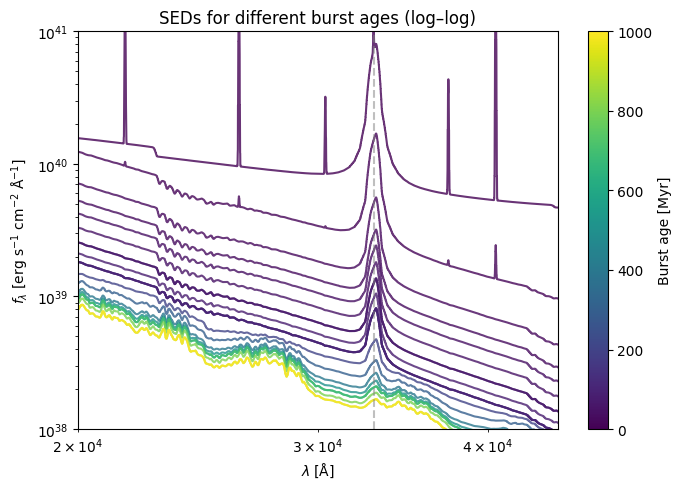

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bagpipes as pipes

years = np.concatenate([
    np.arange(0, 110, 10),
    np.arange(100, 1100, 100)
])

fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

dust = {
    "type": "Calzetti",
    "Av": 0.2,
    "eta": 2.0
}

nebular = {
    "logU": -3.0
}

spec_grid = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

all_seds = {}
for t in years:

    burst = {
        "age": t / 1000.,   # convert Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 0,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs=spec_grid
    )

    wave = model.spectrum[:, 0]
    flux = model.spectrum[:, 1]

    all_seds[t] = {
        "wavelength": wave,
        "flux": flux
    }

    ax.plot(
        wave,
        flux,
        color=cmap(norm(t)),
        alpha=0.8
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$\lambda \; [\mathrm{\AA}]$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")

ax.set_ylim(1e38, 1e41)
ax.set_xlim(2e4, 4.5e4)

ax.axvline(3.3e4, color='grey', linestyle='--', alpha=0.5)
ax.set_title("SEDs for different burst ages (log–log)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()
